# 🫀 Predicting Heart Disease Using Machine Learning

This notebook walks through an **end-to-end machine learning project** that predicts whether a patient has heart disease based on clinical attributes.

We'll go from raw data exploration all the way to hyperparameter-tuned models and final evaluation — covering EDA, feature engineering, and model comparison.

---

## 📑 Table of Contents

1. [Problem Definition](#1.-Problem-Definition)
2. [Data](#2.-Data)
3. [Evaluation](#3.-Evaluation)
4. [Features](#4.-Features)
5. [Exploratory Data Analysis (EDA)](#5.-Exploratory-Data-Analysis)
6. [Modelling](#6.-Modelling)
7. [Feature Engineering & Hyperparameter Tuning](#7.-Feature-Engineering-&-Hyperparameter-Tuning)
8. [Final Model Evaluation](#8.-Final-Model-Evaluation)
9. [Results & Conclusion](#9.-Results-&-Conclusion)

---


## 1. Problem Definition

> **Given medical diagnosis report about a patient, can we predict if the patient has a heart disease or not?**

 Heart-disease is one of the leading causes of death globally. Early detection through diagnosis data can significantly improve patient outcomes. This is a problem with **binary classification** task.

---


## 2. Data

The original data is from the **Cleveland database** available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/heart+Disease).  
it is also available on [Kaggle](https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset).

Note on Dataset Evolution: > the Cleveland database was very limited because of its smaller sample size ($n \approx 301$). To work and imporve the model performance, the project shifted to a comprehensive Heart Failure Prediction Dataset, which aggregates five existing heart datasets (including the UCI ML repository). To maintain codebase consistency, categorical features from the new dataset were mapped to resemble the original UCI dataset. This allowed for a seamless transition to the larger dataset with very less refactoring. The new dataset can be found on [kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

---

## 3. Evaluation

> If we can reach **90 % accuracy** at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.

We will also track **precision**, **recall**, **F1-score**, and **AUC-ROC** because in medical predictions false negatives (missing a sick patient) carry a higher cost than false positives.

---


## 4. Features

Data dictionary describing each feature in the dataset:

| # | Feature | Description |
|:-:|---------|-------------|
| 1 | **age** | Age in years |
| 2 | **sex** | 1 = male · 0 = female |
| 3 | **cp** | Chest pain type (0–3) |
| 4 | **trestbps** | Resting blood pressure (mm Hg) |
| 5 | **chol** | Serum cholesterol (mg/dl) |
| 6 | **fbs** | Fasting blood sugar > 120 mg/dl (1 = true · 0 = false) |
| 7 | **restecg** | Resting ECG results (0–2) |
| 8 | **thalach** | Maximum heart rate achieved |
| 9 | **exang** | Exercise-induced angina (1 = yes · 0 = no) |
| 10 | **oldpeak** | ST depression induced by exercise relative to rest |
| 11 | **slope** | Slope of the peak exercise ST segment (0–2) |
| 12 | **target** | Heart disease (1 = yes · 0 = no) — *the label* |

---


### 🔧 Setting Up the Environment

Import all necessary libraries for data manipulation, visualisation, and modelling.


In [ ]:
# ── Suppress non-critical warnings ────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Core Libraries ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl # Using polars instead of traditional pandas

# ── Plotting configuration ──────────────────────────────────────
%matplotlib inline

# Custom colour palette for a polished look
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
sns.set_theme(
    style="whitegrid",
    palette=PALETTE,
    rc={
        "figure.dpi": 120,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "font.family": "sans-serif",
    },
)

# ── Models ───────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Evaluation & Tuning ───────────────────────────────────
from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    f1_score,
    RocCurveDisplay,
)
# ── Preprocessing ───────────────────────────────────
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


### 📂 Loading the Data


In [2]:
df = pl.read_csv("data/heart-disease.csv")
df.head(10)


age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
i64,str,str,i64,i64,i64,str,i64,str,f64,str,i64
40,"""M""","""ATA""",140,289,0,"""Normal""",172,"""N""",0.0,"""Up""",0
49,"""F""","""NAP""",160,180,0,"""Normal""",156,"""N""",1.0,"""Flat""",1
37,"""M""","""ATA""",130,283,0,"""ST""",98,"""N""",0.0,"""Up""",0
48,"""F""","""ASY""",138,214,0,"""Normal""",108,"""Y""",1.5,"""Flat""",1
54,"""M""","""NAP""",150,195,0,"""Normal""",122,"""N""",0.0,"""Up""",0
39,"""M""","""NAP""",120,339,0,"""Normal""",170,"""N""",0.0,"""Up""",0
45,"""F""","""ATA""",130,237,0,"""Normal""",170,"""N""",0.0,"""Up""",0
54,"""M""","""ATA""",110,208,0,"""Normal""",142,"""N""",0.0,"""Up""",0
37,"""M""","""ASY""",140,207,0,"""Normal""",130,"""Y""",1.5,"""Flat""",1


### 🔍 Quick Data Overview

Before diving into analysis, let's understand the **shape**, **data types**, and **summary statistics** of the dataset.


In [3]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn types:")
for col_name, dtype in zip(df.columns, df.dtypes):
    print(f"  {col_name:12s} → {dtype}")


Dataset shape: 918 rows × 12 columns

Column types:
  age          → Int64
  sex          → String
  cp           → String
  trestbps     → Int64
  chol         → Int64
  fbs          → Int64
  restecg      → String
  thalach      → Int64
  exang        → String
  oldpeak      → Float64
  slope        → String
  target       → Int64


In [4]:
df.describe()


statistic,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
str,f64,str,str,f64,f64,f64,str,f64,str,f64,str,f64
"""count""",918.0,"""918""","""918""",918.0,918.0,918.0,"""918""",918.0,"""918""",918.0,"""918""",918.0
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,"""0""",0.0,"""0""",0.0,"""0""",0.0
"""mean""",53.510893,null,null,132.396514,198.799564,0.233115,null,136.809368,null,0.887364,null,0.553377
"""std""",9.432617,null,null,18.514154,109.384145,0.423046,null,25.460334,null,1.06657,null,0.497414
"""min""",28.0,"""F""","""ASY""",0.0,0.0,0.0,"""LVH""",60.0,"""N""",-2.6,"""Down""",0.0
"""25%""",47.0,null,null,120.0,173.0,0.0,null,120.0,null,0.0,null,0.0
"""50%""",54.0,null,null,130.0,223.0,0.0,null,138.0,null,0.6,null,1.0
"""75%""",60.0,null,null,140.0,267.0,0.0,null,156.0,null,1.5,null,1.0
"""max""",77.0,"""M""","""TA""",200.0,603.0,1.0,"""ST""",202.0,"""Y""",6.2,"""Up""",1.0


#### Checking for Missing Values


In [5]:
null_counts = df.null_count()
print("Missing values per column:")
print(null_counts)


Missing values per column:
shape: (1, 12)
┌─────┬─────┬─────┬──────────┬───┬───────┬─────────┬───────┬────────┐
│ age ┆ sex ┆ cp  ┆ trestbps ┆ … ┆ exang ┆ oldpeak ┆ slope ┆ target │
│ --- ┆ --- ┆ --- ┆ ---      ┆   ┆ ---   ┆ ---     ┆ ---   ┆ ---    │
│ u32 ┆ u32 ┆ u32 ┆ u32      ┆   ┆ u32   ┆ u32     ┆ u32   ┆ u32    │
╞═════╪═════╪═════╪══════════╪═══╪═══════╪═════════╪═══════╪════════╡
│ 0   ┆ 0   ┆ 0   ┆ 0        ┆ … ┆ 0     ┆ 0       ┆ 0     ┆ 0      │
└─────┴─────┴─────┴──────────┴───┴───────┴─────────┴───────┴────────┘


### 🏷️ Encoding Categorical Features

Several columns contain string labels (e.g. `"M"`, `"ATA"`, `"Normal"`) which were numeric in origianl dataset.
We map them to integer codes, this ensures that the model remains compatible with the original UCI Cleveland codebase


In [6]:
# Mapping categorical columns to integer codes
mapping = {
    "sex":     {"M": 1, "F": 0},
    "cp":      {"ATA": 1, "TA": 0, "NAP": 2, "ASY": 3},
    "restecg": {"Normal": 0, "ST": 1, "LVH": 2},
    "exang":   {"Y": 1, "N": 0},
    "slope":   {"Flat": 1, "Up": 0, "Down": 2},
}

df = df.with_columns([
    pl.col(col).replace(mapping[col]).cast(pl.Int64)
    for col in mapping
])

df.head()


age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64
40,1,1,140,289,0,0,172,0,0.0,0,0
49,0,2,160,180,0,0,156,0,1.0,1,1
37,1,1,130,283,0,1,98,0,0.0,0,0
48,0,3,138,214,0,0,108,1,1.5,1,1
54,1,2,150,195,0,0,122,0,0.0,0,0


---

## 5. Exploratory Data Analysis

Before building any model, lets explore the data to uncover **patterns**, **class imbalances**, **correlations**, and **outliers**.


### 5.1 Target Distribution

First, let's check if the classes are balanced — this heavily influences model choice and evaluation metrics.


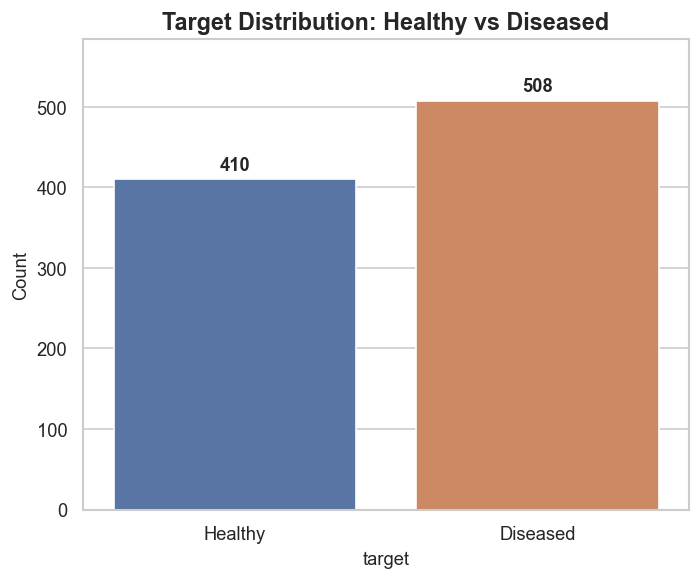

In [107]:
fig,ax = plt.subplots(figsize=(6,5))
sns.countplot(data=df, x="target",hue="target",ax=ax,palette=PALETTE[:2],edgecolor="white");

# Add count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontweight="bold", fontsize=11, padding=3)

# Customising the plot
ax.set(title="Count of healthy and diseased people");
ax.set_title("Target Distribution: Healthy vs Diseased")
ax.set_ylabel("Count")
ax.set_xticklabels(["Healthy", "Diseased"])
ax.set_ylim(0, max(target_counts["count"].to_list()) * 1.15)
ax.legend().remove()
plt.tight_layout()
plt.show()


> 📊 The dataset shows a **moderate class imbalance**. There are more patients with heart disease than without. This isn't extreme, we can proceed without resampling but have to watchout on recall for the minority class.


### 5.2 Heart Disease by Chest Pain Type

Chest pain type is one of the most clinically significant features. Let's see how it relates to the target.


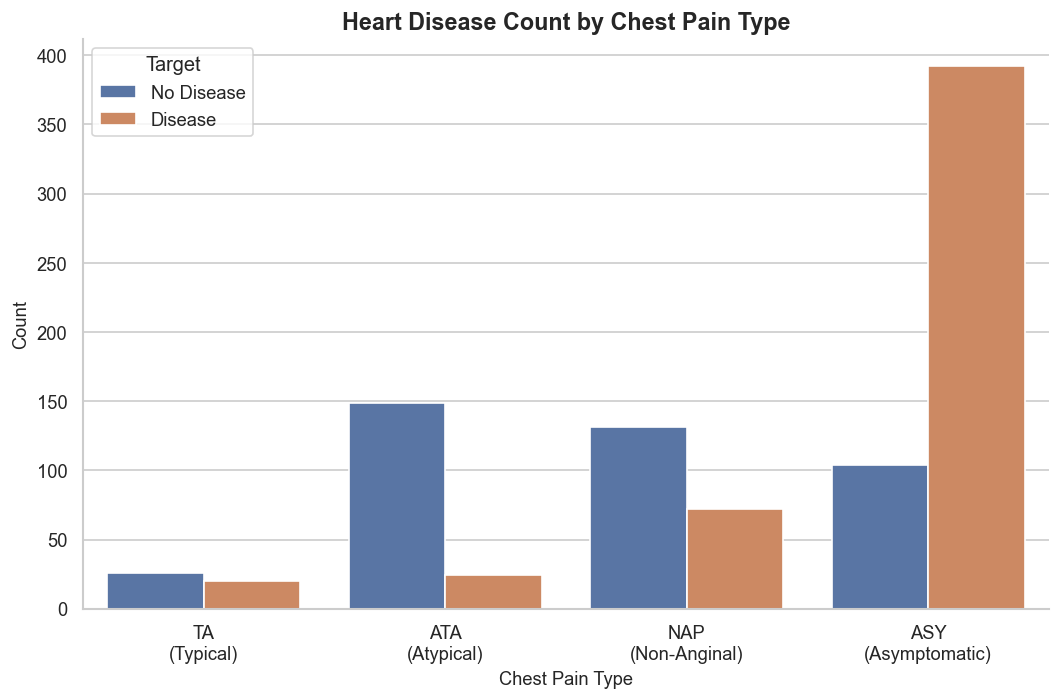

In [108]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(data=df, x="cp", hue="target", palette=PALETTE[:2], ax=ax, edgecolor="white")

ax.set_xticklabels(["TA\n(Typical)", "ATA\n(Atypical)", "NAP\n(Non-Anginal)", "ASY\n(Asymptomatic)"])
ax.set_title("Heart Disease Count by Chest Pain Type")
ax.set_xlabel("Chest Pain Type")
ax.set_ylabel("Count")
ax.legend(title="Target", labels=["No Disease", "Disease"])
sns.despine()
plt.tight_layout()
plt.show()


> 💡 **Asymptomatic (ASY)** chest pain is strongly associated with heart disease — this feature is likely to be highly predictive.


### 5.3 Correlation Heatmap

A correlation matrix helps identify which features are most related to the target and to each other.


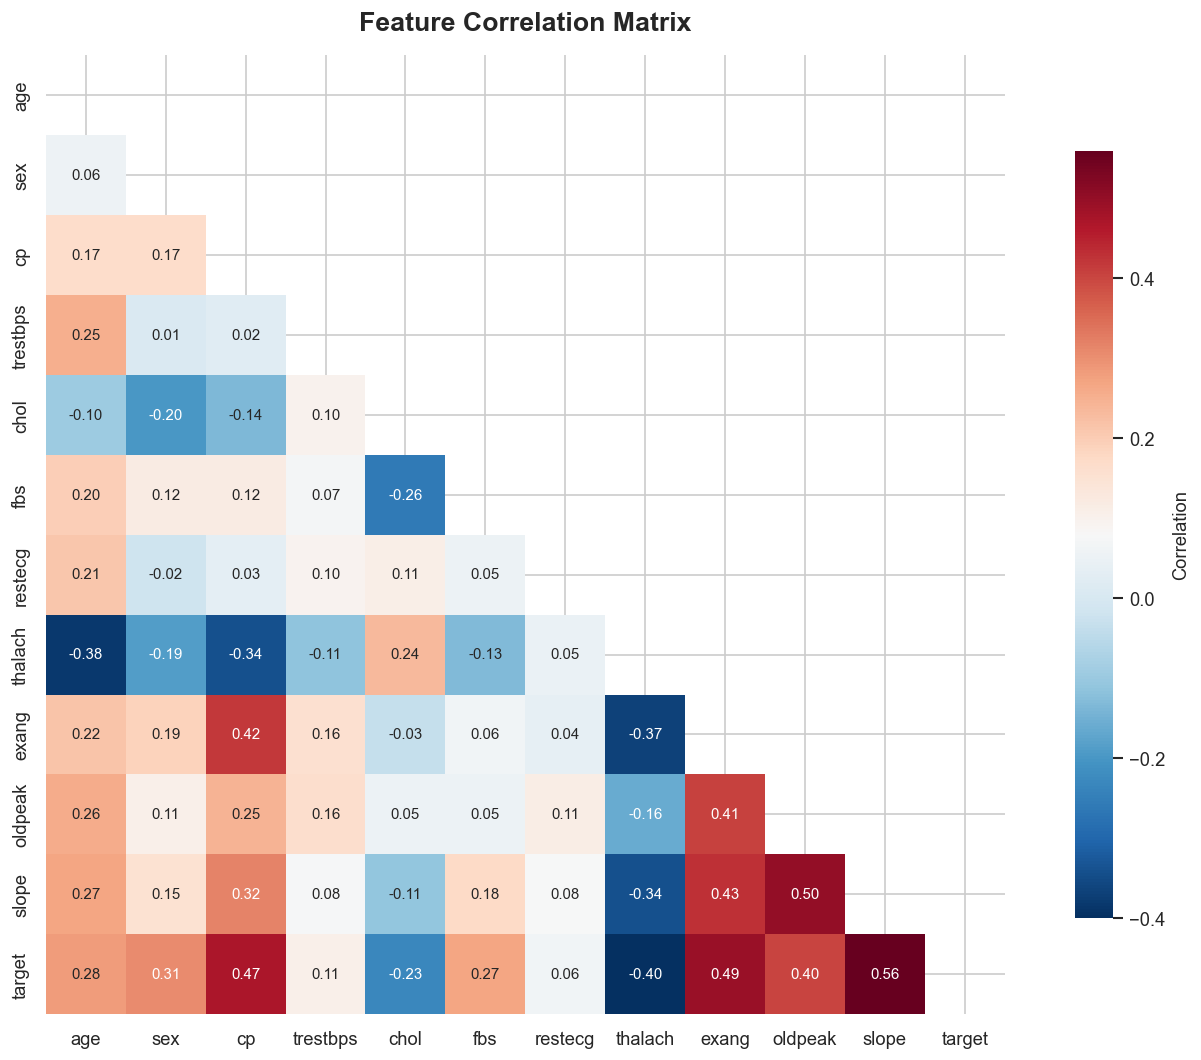

In [117]:
corr_mat = df.corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    data=corr_mat,
    annot=True,
    fmt=".2f",
    mask=mask,
    cmap="RdBu_r",
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot_kws={"size": 9},
)
ax.set_title("Feature Correlation Matrix", fontsize=16, pad=15)
ax.set_xticklabels(df.columns)
ax.set_yticklabels(df.columns)
plt.tight_layout()
plt.show()


> 🔗 **Key observations from the correlation matrix:**
> - `oldpeak`,`exang`,`cp` and `slope` have notable **positive** correlation with the target
> - `thalach` (max heart rate) shows a **negative** correlation — higher heart rate is associated with *less* disease
> - No severe multicollinearity between features, (good for Logistic Regression)


### 5.5 Age Distribution & Outliers


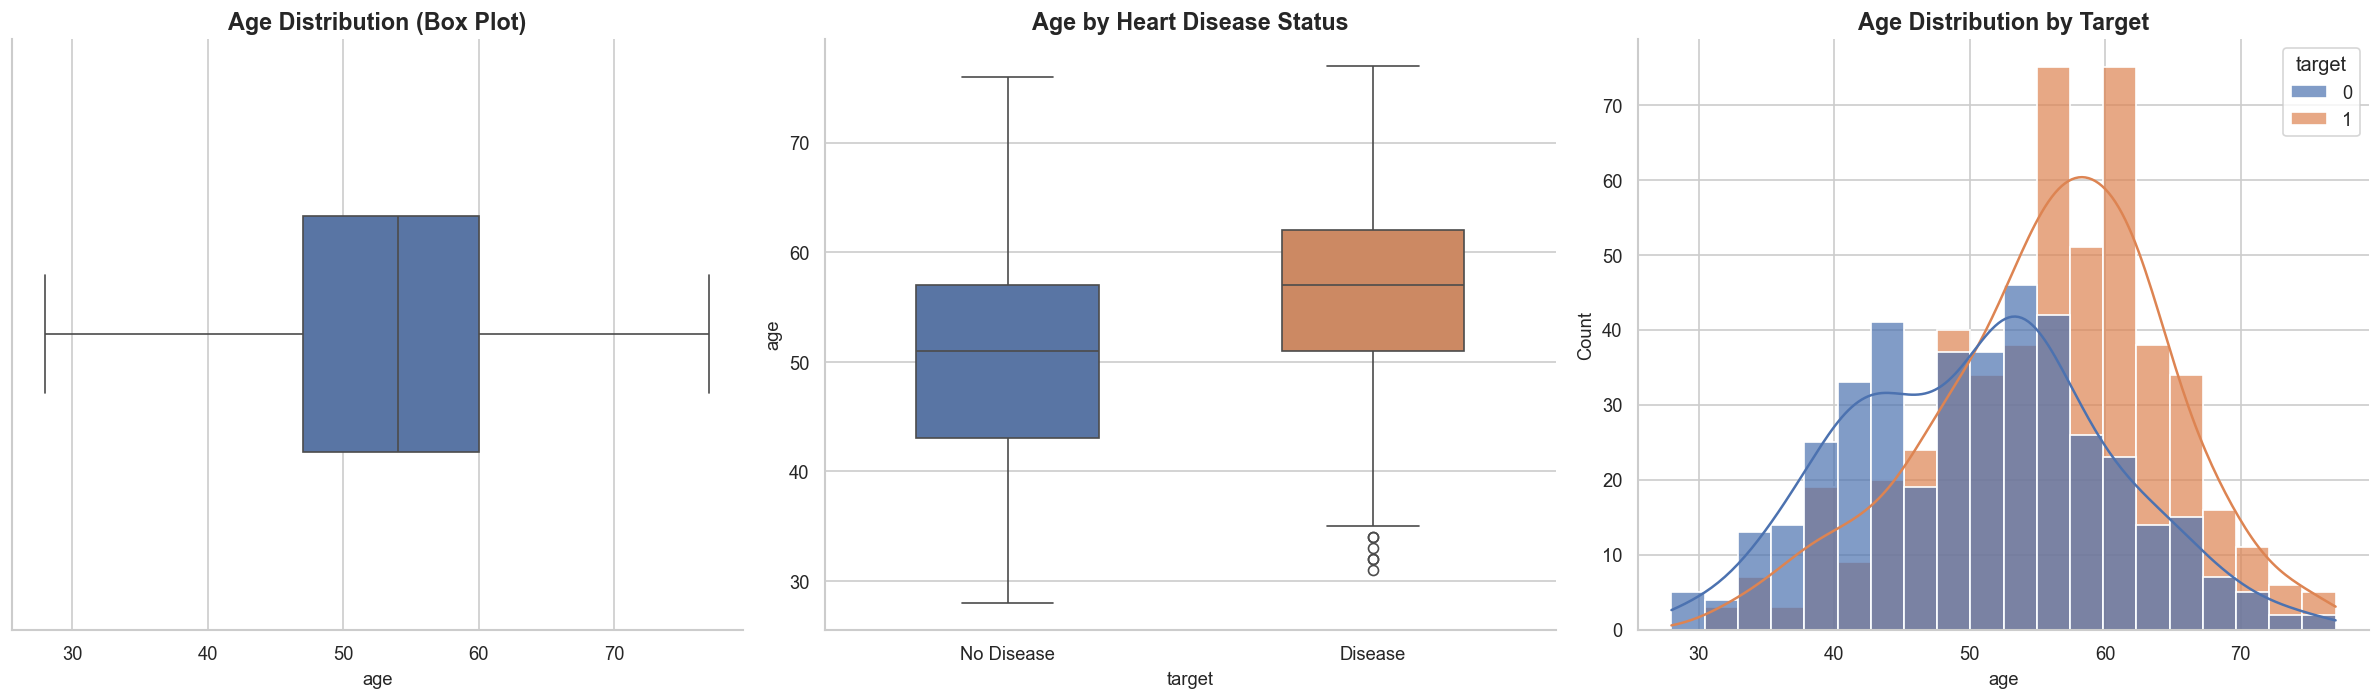

In [122]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(20, 6))

# Box plot – overall age
sns.boxplot(data=df, x="age", ax=ax0, color=PALETTE[0], width=0.4)
ax0.set_title("Age Distribution (Box Plot)")

# Box plot – age by target
sns.boxplot(data=df, x="target", y="age", ax=ax1, palette=PALETTE[:2], width=0.5)
ax1.set_xticklabels(["No Disease", "Disease"])
ax1.set_title("Age by Heart Disease Status")

# Histogram – age coloured by target
sns.histplot(data=df, x="age", hue="target", bins=20, kde=True, ax=ax2,
             palette=PALETTE[:2], alpha=0.7, edgecolor="white")
ax2.set_title("Age Distribution by Target")

for ax in (ax0, ax1, ax2):
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


> 📈 Patients with heart disease tend to be **older** on average. The KDE overlay confirms this with a rightward shift in the age distribution for the disease group.


---

## 6. Modelling

We compare three classifiers as a baseline **before** any feature engineering:

| Model | Library | Type |
|-------|---------|------|
| Logistic Regression | `sklearn` | Linear |
| Random Forest | `sklearn` | Ensemble (Bagging) |
| XGBoost | `xgboost` | Ensemble (Boosting) |

### 6.1 Train / Test Split


In [12]:
# Separate features (X) and target (y)
X = df.drop("target")
y = df["target"]

# 80/20 split, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")


Training samples : 734
Testing samples  : 184


### 6.2 Baseline Model Comparison

Let's train each model on the raw (un-scaled) data and record train vs test accuracy.


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(random_state=48),
    "XGBoost":             XGBClassifier(
                               random_state=48,
                               use_label_encoder=False,
                               eval_metric="logloss",
                           ),
}

print(f"{'Model':25s}  {'Train':>8s}  {'Test':>8s}")
print("─" * 47)

for name, model in models.items():
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score  = model.score(X_test, y_test)
    print(f"{name:25s}  {train_score:8.4f}  {test_score:8.4f}")


Model                         Train      Test
───────────────────────────────────────────────
Logistic Regression          0.8597    0.8424
Random Forest                1.0000    0.8587


XGBoost                      1.0000    0.8641


> ⚠️ Notice the gap between train and test scores for **Random Forest and XGBoost**: a sign of overfitting. Feature engineering and hyperparameter tuning should help close this gap.


---

## 7. Feature Engineering & Hyperparameter Tuning

### 7.1 Preprocessing Pipeline

We build a `ColumnTransformer` that:
- **Z-score scales** continuous features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`)
- **One-hot encodes** categorical features (`cp`, `restecg`, `slope`)
- Passes through remaining binary features (`sex`, `fbs`, `exang`) unchanged


In [14]:
# Define column groups
scale_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols   = ["cp", "restecg", "slope"]

# Build the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), scale_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="passthrough",
)


### 7.2 Logistic Regression — Grid Search


In [15]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

lr_params = {
    "model__C":      np.logspace(-3, 3, 20),
    "model__solver": ["liblinear", "lbfgs"],
}

grid_lr = GridSearchCV(lr_pipeline, lr_params, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': array([1.0000...00000000e+03]), 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

In [16]:
best_lr = grid_lr.best_estimator_

print(f"Best params : {grid_lr.best_params_}")
print(f"CV Score    : {grid_lr.best_score_:.4f}")
print(f"Train Score : {best_lr.score(X_train, y_train):.4f}")
print(f"Test Score  : {best_lr.score(X_test, y_test):.4f}")


Best params : {'model__C': np.float64(0.6951927961775606), 'model__solver': 'liblinear'}
CV Score    : 0.8624
Train Score : 0.8706
Test Score  : 0.8533


### 7.3 Random Forest — Randomised Search


In [17]:
rfc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=48)),
])

rfc_params = {
    "model__n_estimators":      [100, 200, 500],
    "model__max_depth":         [5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf":  [1, 2, 5],
    "model__max_features":      ["sqrt", "log2"],
}

grid_rfc = RandomizedSearchCV(
    rfc_pipeline, rfc_params,
    cv=5, n_iter=20, scoring="accuracy", n_jobs=-1, random_state=48,
)
grid_rfc.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=48))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [18]:
best_rfc = grid_rfc.best_estimator_

print(f"Best params : {grid_rfc.best_params_}")
print(f"CV Score    : {grid_rfc.best_score_:.4f}")
print(f"Train Score : {best_rfc.score(X_train, y_train):.4f}")
print(f"Test Score  : {best_rfc.score(X_test, y_test):.4f}")


Best params : {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 5}
CV Score    : 0.8678
Train Score : 0.8910
Test Score  : 0.8696


> ✅ After finetuning, the Random Forest model exhibits **reduced overfitting** and much better generalisation.


### 7.4 XGBoost — Randomised Search


In [19]:
xgbc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=48,
        use_label_encoder=False,
        eval_metric="logloss",
    )),
])

xgbc_params = {
    "model__n_estimators":     [100, 200, 300, 500],
    "model__max_depth":        [3, 5, 7, 10],
    "model__learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "model__subsample":        [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.8, 1.0],
    "model__gamma":            [0, 0.1, 0.3, 0.5],
}

r_xgbc = RandomizedSearchCV(
    xgbc_pipeline, xgbc_params,
    cv=5, n_iter=20, scoring="accuracy", n_jobs=-1, random_state=48,
)
r_xgbc.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.5, 0.7, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [20]:
best_xgbc = r_xgbc.best_estimator_

print(f"Best params : {r_xgbc.best_params_}")
print(f"CV Score    : {r_xgbc.best_score_:.4f}")
print(f"Train Score : {best_xgbc.score(X_train, y_train):.4f}")
print(f"Test Score  : {best_xgbc.score(X_test, y_test):.4f}")


Best params : {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__gamma': 0.5, 'model__colsample_bytree': 0.7}
CV Score    : 0.8719
Train Score : 0.9114
Test Score  : 0.8859


> ✅ After finetuning, XGBoostClassifier exhibits **reduced overfitting** and much better generalisation.


### 7.5 📊 Model Comparison (After Tuning)


In [129]:
tuned_models = {
    "Logistic Regression": (grid_lr, best_lr),
    "Random Forest":       (grid_rfc, best_rfc),
    "XGBoost":             (r_xgbc, best_xgbc),
}

rows = []
for name, (search, model) in tuned_models.items():
    rows.append({
        "Model":       name,
        "CV Score":    round(search.best_score_, 4),
        "Train Score": round(model.score(X_train, y_train), 4),
        "Test Score":  round(model.score(X_test, y_test), 4),
    })

comparison_df = pl.DataFrame(rows)
comparison_df

Model,CV Score,Train Score,Test Score
str,f64,f64,f64
"""Logistic Regression""",0.8624,0.8706,0.8533
"""Random Forest""",0.8678,0.891,0.8696
"""XGBoost""",0.8719,0.9114,0.8859


---

## 8. Final Model Evaluation

Now let's perform a deeper evaluation of our fine-tuned models using the held-out test set.

### 8.1 Confusion Matrix


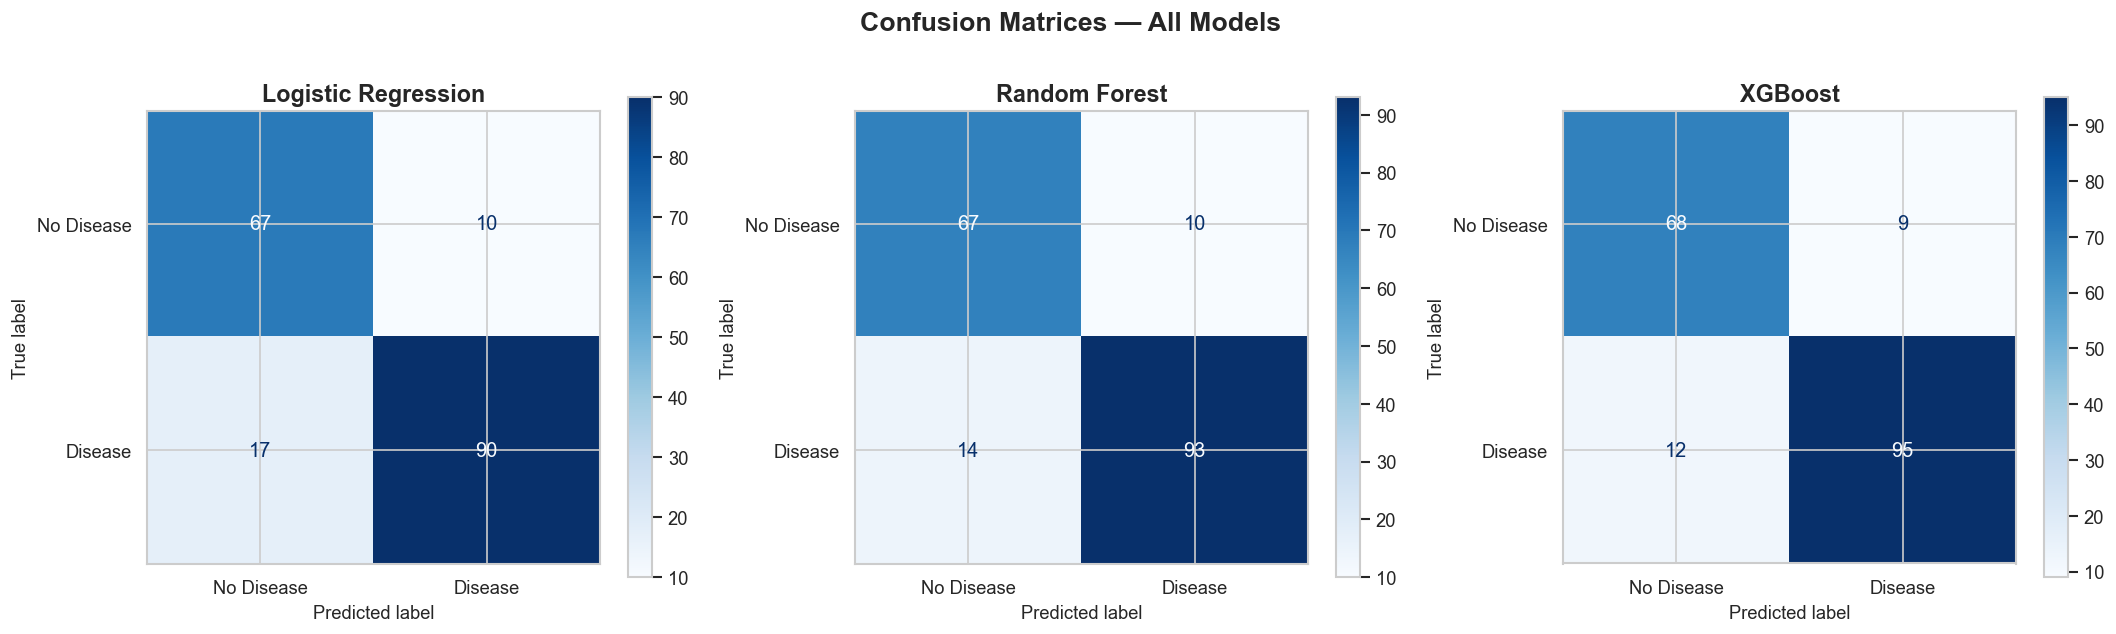

In [130]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))

# LR
ConfusionMatrixDisplay.from_estimator(best_lr, X_test, y_test, cmap="Blues", ax=ax0, display_labels=["No Disease", "Disease"])
ax0.set_title("Logistic Regression")

# RF
ConfusionMatrixDisplay.from_estimator(best_rfc, X_test, y_test, cmap="Blues", ax=ax1, display_labels=["No Disease", "Disease"])
ax1.set_title("Random Forest")

# XGB
ConfusionMatrixDisplay.from_estimator(best_xgbc, X_test, y_test, cmap="Blues", ax=ax2, display_labels=["No Disease", "Disease"])
ax2.set_title("XGBoost")

plt.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


> 🔍 The confusion matrices reveal how each model handles **false positives** (healthy predicted as sick) vs **false negatives** (sick predicted as healthy). In a medical diagnosis, minimising false negatives is critical.


### 8.2 Classification Report


In [138]:
# RF
print("─" * 55)
print("Random Forest")
print("─" * 55)
print(classification_report(y_test, best_rfc.predict(X_test), target_names=["No Disease", "Disease"]))

# XGB
print("─" * 55)
print("XGBoost")
print("─" * 55)
print(classification_report(y_test, best_xgbc.predict(X_test), target_names=["No Disease", "Disease"]))


───────────────────────────────────────────────────────
Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Disease       0.83      0.87      0.85        77
     Disease       0.90      0.87      0.89       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184

───────────────────────────────────────────────────────
XGBoost
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Disease       0.85      0.88      0.87        77
     Disease       0.91      0.89      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184



### 8.3 Cross-Validation Scores

5-fold cross-validation on the **full dataset** gives a more robust estimate of model performance.


In [24]:
cv_scores_xgb = cross_val_score(best_xgbc, X, y, cv=5, verbose=0)

print(f"Cross-Validation Scores : {np.round(cv_scores_xgb, 4)}")
print(f"Mean CV Accuracy        : {cv_scores_xgb.mean():.4f}")
print(f"Std  CV Accuracy        : {cv_scores_xgb.std():.4f}")


Cross-Validation Scores : [0.8696 0.837  0.8315 0.8415 0.7814]
Mean CV Accuracy        : 0.8322
Std  CV Accuracy        : 0.0286


In [140]:
cv_scores_rfc = cross_val_score(best_rfc,X,y,cv=5,verbose=0)
print(f"Cross-Validation Scores : {np.round(cv_scores_rfc, 4)}")
print(f"Mean CV Accuracy        : {cv_scores_rfc.mean():.4f}")
print(f"Std  CV Accuracy        : {cv_scores_rfc.std():.4f}")

Cross-Validation Scores : [0.913  0.8424 0.8478 0.8415 0.7432]
Mean CV Accuracy        : 0.8376
Std  CV Accuracy        : 0.0543


### 8.4 ROC Curve Comparison

The **ROC curve** plots the true positive rate against the false positive rate at various thresholds. A higher AUC indicates better discrimination.


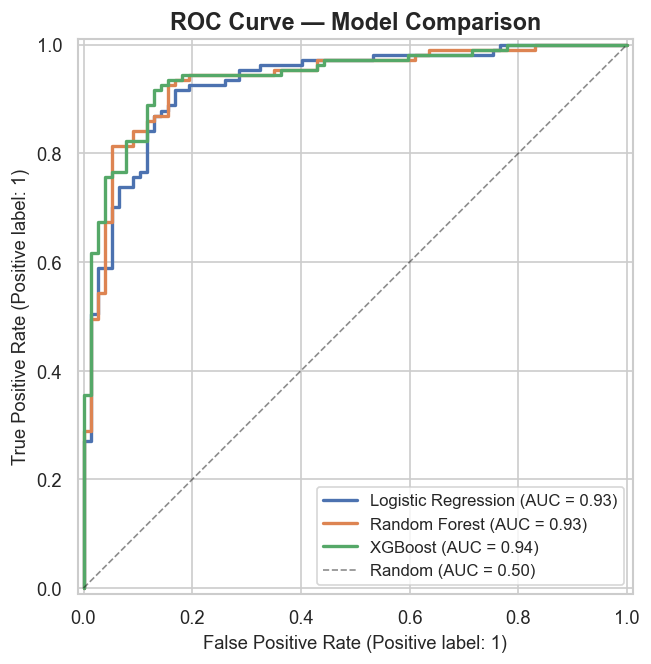

In [143]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(best_lr,   X_test, y_test, ax=ax, name="Logistic Regression", color=PALETTE[0], lw=2)
RocCurveDisplay.from_estimator(best_rfc,  X_test, y_test, ax=ax, name="Random Forest",       color=PALETTE[1], lw=2)
RocCurveDisplay.from_estimator(best_xgbc, X_test, y_test, ax=ax, name="XGBoost",             color=PALETTE[2], lw=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, lw=1, label="Random (AUC = 0.50)")
ax.set_title("ROC Curve — Model Comparison")
ax.legend(loc="lower right", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


---

## 9. Results & Conclusion

| Metric | Random Forest | XGBoost |
|--------|:------------:|:-------:|
| Raw Recall | Slight edge | — |
| Cross-Validation | Slight edge | — |
| **Precision–Recall balance** | — | ✅ **Better** |
| **AUC-ROC** | — | ✅ **Higher** |
| Overfitting risk | Higher | Lower |
---


### 🔑 Key Takeaways

1. **XGBoost** gives the best overall balance between precision and recall, and shows less overfitting after hyperparameter tuning.
2. **Random Forest** has a marginal edge over XGBoost in raw recall and CV average
3. **Feature engineering** (Z-score scaling + one-hot encoding via `ColumnTransformer`) materially improved all models compared to their baseline scores.
4. All models benefited from hyperparameter tuning, with the train–test gap narrowing significantly.

> **🏆 Recommendation:** Use the tuned **XGBoost** model as the primary classifier for this heart-disease prediction task since it has better over-all accuracy, precision, recall on True Positives

---

*· Built with Polars, Numpy, Seasbon, Matplotlib, scikit-learn & XGBoost*